In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.8 MB/s eta 0:00:00:00:0100:01


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import re
import string
from collections import Counter
from torch.utils.data import Dataset,DataLoader
from gensim.models import FastText
import numpy as np
import torch.nn as nn
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler
from tqdm import tqdm
import json

In [ ]:
def clean_text(text):
    text = text.lower()
    # Remove URLs (common spam vector)
    text = re.sub(r'http\S+|www\S+|https\S+', ' URL ', text)
    # Handle email addresses (spam indicator)
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)    
    # Keep digits but normalize excessive repetition
    text = re.sub(r'(\d)\1{3,}', r'\1\1\1', text)      
    # Remove punctuation except $ and % (spam signals)
    text = re.sub(r'[^\w\s$%]', ' ', text)    
    # Normalize currency
    text = re.sub(r'\$\s*(\d+)', r'$\1', text)    
    # Collapse whitespace
    text = " ".join(text.split())   
    return text

In [4]:
def prepare_sms_data(file_path:str):
    df= pd.read_csv(file_path,sep='\t', names=['label', 'message'])
    df['label']=df['label'].map({'ham':0,'spam':1})
    df['message']=df['message'].apply(clean_text)
    df = df[df['message'].str.strip().astype(bool)]
    train_texts,test_texts,train_labels,test_labels=train_test_split(df['message'].values,df['label'].values,test_size=0.1,random_state=42)
    return train_texts,test_texts,train_labels,test_labels

In [5]:
tr_text,t_text,tr_label,t_label=prepare_sms_data("SMSSpamCollection")

In [10]:
len(t_label)

557

In [6]:
def get_embedding_matrix(model_path:str,vocab:dict):
    """ 
    Loads gensim FastText and creates a pytorch embedding matrix from FastText 
    """

    try: 
        ft_model=FastText.load(model_path)
        embed_dim=ft_model.vector_size
        matrix_len = len(vocab)+1
        weight_matrix=np.zeros((matrix_len,embed_dim))

        for words, i in vocab.items():
            weight_matrix[i]=ft_model.wv[words]
        return torch.tensor(weight_matrix,dtype=torch.float32)
    except FileNotFoundError:
        print("could not find the.npy files")
        raise

In [7]:
class SMSvocab:
    def __init__(self,min_freq=1):
        self.itos={0:"<pad>",1:"<unk>"}
        self.stoi={"<pad>":0,"<unk>":1}
        self.min_freq=min_freq

    def build_voabulary(self,sentence_list):
        frequencies=Counter()
        idx=2
        for sentence in sentence_list:
            for word in str(sentence).lower().split():
                frequencies[word]+=1
        for word, count in frequencies.items():
            if count >= self.min_freq:
                self.stoi[word]=idx
                self.itos[idx]=word
                idx+=1
    def encode(self,text):
        return [self.stoi.get(w.lower(), self.stoi["<unk>"]) for w in str(text).split()]
    def __len__(self):
        return len(self.stoi)
    
    def save_vocab(self, filepath):
        """
        Saves the stoi dictionary to a JSON file.
        """
        with open(filepath, 'w') as f:
            json.dump(self.stoi, f, indent=4)
        print(f"✅ Vocabulary saved to {filepath}")

    @classmethod
    def load_vocab(cls, filepath):
        """
        Creates an instance of SMSvocab from a saved JSON file.
        Useful for inference.
        """
        with open(filepath, 'r') as f:
            stoi = json.load(f)
        
        # Create a new instance
        vocab_instance = cls()
        vocab_instance.stoi = stoi
        # Reconstruct itos from stoi
        vocab_instance.itos = {v: k for k, v in stoi.items()}
        return vocab_instance

In [8]:
class SMSdataset(Dataset):
    def __init__(self,texts,labels,vocab,max_len=50):
        self.labels = labels
        self.max_len = max_len
        
        # Pre-calculate sequences once to save CPU time during training
        self.sequences = []
        for text in texts:
            tokens = vocab.encode(text)
            
            # Efficient padding/truncating
            if len(tokens) < max_len:
                tokens += [0] * (max_len - len(tokens))
            else:
                tokens = tokens[:max_len]
            
            self.sequences.append(tokens)

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self,index):
        x = torch.tensor(self.sequences[index], dtype=torch.long)
        y = torch.tensor(self.labels[index], dtype=torch.float32)
        return x, y

In [9]:
vocab=SMSvocab(min_freq=2)
vocab.build_voabulary(tr_text)
vocab.save_vocab("vocab.json")
embedding_matrix=get_embedding_matrix("spam_fasttext_gensim.model",vocab.stoi)
train_ds=SMSdataset(tr_text,tr_label,vocab,max_len=50)
test_ds=SMSdataset(t_text,t_label,vocab,max_len=50)

✅ Vocabulary saved to vocab.json
could not find the.npy files


FileNotFoundError: [Errno 2] No such file or directory: 'spam_fasttext_gensim.model'

In [10]:
# Hyperparameters for the T4 GPU
BATCH_SIZE = 64
# num_workers should be roughly 2-4x the number of CPU cores for pre-fetching
NUM_WORKERS = 2 

# 1. Training Loader
# shuffle=True is MANDATORY for training to ensure the model doesn't 
# learn the order of the dataset.
train_loader = DataLoader(
    dataset=train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    pin_memory=True  # Speeds up data transfer from CPU to GPU
)

# 2. Validation Loader
# shuffle=False because we only care about performance on a fixed set.
val_loader = DataLoader(
    dataset=test_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [11]:
class SelfAttention(nn.Module):
    def __init__(self,d_x):
        super().__init__()

        self.d_x=d_x
        self.scale=torch.sqrt(torch.tensor(d_x, dtype=torch.float32))

        self.q=nn.Linear(d_x,d_x)
        self.k=nn.Linear(d_x,d_x)
        self.v=nn.Linear(d_x,d_x)
    
    def forward(self,x,mask=None):
        Q,K,V=self.q(x),self.k(x),self.v(x)

        attn_score=torch.matmul(Q,K.transpose(-2,-1))/self.scale
        if mask is not None:
            # mask shape: (batch, seq) -> (batch, 1, seq) for broadcasting
            mask=mask.unsqueeze(1)
            attn_score=attn_score.masked_fill(mask==0,float('-inf'))

        weights=F.softmax(attn_score,dim=-1)
        context=torch.matmul(weights,V)
        return context,weights

In [12]:
class SpamAttentionClassifier(nn.Module):
    def __init__(self,embedding_matrix,hidden_dim=128):
        super().__init__()
        vocab_size,embed_dim=embedding_matrix.shape
        self.embedding=nn.Embedding.from_pretrained(embedding_matrix,freeze=False)
        self.lstm=nn.LSTM(embed_dim,hidden_dim,batch_first=True,bidirectional=True)
        self.attention=SelfAttention(hidden_dim*2)
        self.fc=nn.Linear(hidden_dim*2,1)
        self.sigmoid=nn.Sigmoid()
    def forward(self,x):
        # Create padding mask: 1 for real tokens, 0 for pad (index 0)
        mask=(x!=0).float()  # shape: (batch, seq_len)
        x=self.embedding(x)
        out, (hn,cn)=self.lstm(x)
        context_seq,weights=self.attention(out,mask=mask)
        # Masked mean pooling: average only over real tokens
        mask_expanded=mask.unsqueeze(-1)  # (batch, seq, 1)
        context=(context_seq*mask_expanded).sum(dim=1)/mask_expanded.sum(dim=1).clamp(min=1)
        return self.fc(context),weights

In [13]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model.to(device)
    
    # Using BCEWithLogitsLoss for numerical stability
    pos_weight = torch.tensor([7.0]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Scheduler to help with that final 98% push
    # scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            
            # Standard Forward Pass (FP32)
            outputs, _ = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward Pass
            loss.backward()
            
            # --- GRADIENT CLIPPING ---
            # This prevents the 0.5 stagnation by keeping gradients in a healthy range
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        # scheduler.step(val_loss)
        print(f"Epoch {epoch+1} Summary: Val Loss {val_loss:.4f}, Val Acc {val_acc:.4f}")

def evaluate(model, loader, criterion):
    model.eval()
    losses, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            outputs, _ = model(inputs)
            loss = criterion(outputs, labels)
            losses += loss.item()
            
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return losses / len(loader), correct / total

In [14]:
model=SpamAttentionClassifier(embedding_matrix=embedding_matrix)
train_model(model,train_loader,val_loader,epochs=15)

Epoch 1: 100%|██████████| 79/79 [00:01<00:00, 41.88it/s, loss=0.852] 


Epoch 1 Summary: Val Loss 0.2894, Val Acc 0.9156


Epoch 2: 100%|██████████| 79/79 [00:00<00:00, 95.60it/s, loss=3.84]    


Epoch 2 Summary: Val Loss 0.1867, Val Acc 0.9659


Epoch 3: 100%|██████████| 79/79 [00:00<00:00, 92.65it/s, loss=0.0354]  


...

Epoch 13 Summary: Val Loss 0.1980, Val Acc 0.9838


Epoch 14: 100%|██████████| 79/79 [00:00<00:00, 100.75it/s, loss=0.000729]


Epoch 14 Summary: Val Loss 0.2215, Val Acc 0.9856


Epoch 15: 100%|██████████| 79/79 [00:00<00:00, 102.51it/s, loss=2.62e-5] 


Epoch 15 Summary: Val Loss 0.2423, Val Acc 0.9838


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

def predict_and_visualize(text, model, vocab, max_len=50):
    """
    Predicts spam/ham and visualizes the attention weights spotlight.
    """
    model.eval()
    device = next(model.parameters()).device
    
    cleaned_text = clean_text(text) 
    
    # --- STEP 2: Preprocess & Numericalize ---
    tokens = cleaned_text.split()
    # Keep track of original tokens for labeling the axis
    display_tokens = tokens[:max_len]
    
    indexed = vocab.encode(cleaned_text)
    if len(indexed) < max_len:
        indexed += [0] * (max_len - len(indexed))
        # Add padding labels for the plot
        display_tokens += ["<pad>"] * (max_len - len(display_tokens))
    else:
        indexed = indexed[:max_len]

    # 2. Inference
    # input shape: [1, max_len]
    input_tensor = torch.tensor(indexed).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # raw_output is the logit, weights is [1, max_len, max_len]
        logits, weights = model(input_tensor)
        prediction = torch.sigmoid(logits).item()

    # 3. Process Weights for Visualization
    # We take the weights for the first (and only) batch
    # Shape becomes [max_len, max_len]
    attn_matrix = weights[0].cpu().numpy()
    
    # We only care about the words we actually have (not the whole max_len)
    actual_len = len(text.split())
    trimmed_weights = attn_matrix[:actual_len, :actual_len]
    trimmed_tokens = display_tokens[:actual_len]

    # 4. Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        trimmed_weights, 
        annot=True, 
        cmap='viridis', 
        xticklabels=trimmed_tokens, 
        yticklabels=trimmed_tokens
    )
    
    plt.title(f"Prediction: {'SPAM' if prediction > 0.5 else 'HAM'} ({prediction:.2%})")
    plt.xlabel("Keys (Context words)")
    plt.ylabel("Queries (Current word)")
    plt.xticks(rotation=45)
    plt.show()

    return prediction

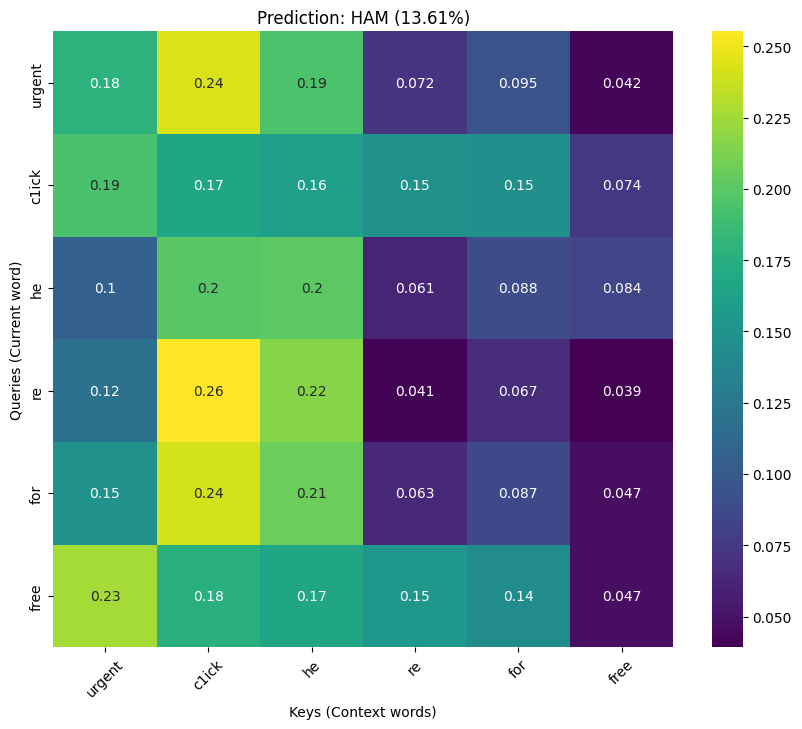

0.13608387112617493

In [28]:
predict_and_visualize("URGENT: C1ick he.re for free m0ney",model,vocab,max_len=100)

In [17]:
torch.save(model.state_dict(),'Spam_Classifier.pth')

In [18]:
%ls

sample_data/         spam_fasttext_gensim.model
SMSSpamCollection    spam_fasttext_gensim.model.wv.vectors_ngrams.npy
Spam_Classifier.pth
